In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a folder in your Drive specifically for this project's data
SAVE_DIR = '/content/drive/MyDrive/Stock_Trading_Project_Data'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved to: {SAVE_DIR}")

Mounted at /content/drive
Data will be saved to: /content/drive/MyDrive/Stock_Trading_Project_Data


In [2]:
!git clone https://ciot.imis.ncku.edu.tw:25388/Amy/stock_project_for_class.git

Cloning into 'stock_project_for_class'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 41 (delta 9), reused 0 (delta 0), pack-reused 18 (from 1)
Receiving objects: 100% (41/41), 43.54 KiB | 454.00 KiB/s, done.
Resolving deltas: 100% (9/9), done.


In [3]:
import os
from pathlib import Path

print(os.getcwd())

os.chdir('/content/stock_project_for_class')
print(os.getcwd())

# # Iterate and print files in the current directory
# for path in Path('.').iterdir():
#     # if path.is_file():
#     print(path.name)

/content
/content/stock_project_for_class


In [ ]:
import pandas as pd
import time
from stock_api import get_taiwan_stock_data

# Mount Drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/Stock_Project_Data/Raw_Stocks'
os.makedirs(SAVE_DIR, exist_ok=True)

# Train on just 30 highly liquid stocks to save time
TRAIN_STOCKS = [
    "2330", "2317", "2454", "2308", "2303", "2382", "3231", "2356", "2379", "3034",
    "2881", "2882", "2891", "2886", "2884", "2885", "2892", "2880", "2883", "2887",
    "2002", "1216", "1301", "1303", "2603", "2609", "2412", "3045", "4904", "2912"
]

START_DATE = "2016-01-01"
END_DATE = "2026-05-31"

print(f"Starting fault-tolerant download for {len(TRAIN_STOCKS)} stocks...")

for stock in TRAIN_STOCKS:
    file_path = f"{SAVE_DIR}/{stock}_10yr.csv"

    # Fault Tolerance: Skip if already downloaded!
    if os.path.exists(file_path):
        print(f"[{stock}] already exists. Skipping...")
        continue

    print(f"[{stock}] Fetching 10 years of data...")
    try:
        df = get_taiwan_stock_data(stock, START_DATE, END_DATE)
        if df is not None and not df.empty:
            df['stock_code'] = stock
            df.to_csv(file_path, index=False)
            print(f"[{stock}] Saved {len(df)} rows to Drive.")
        else:
            print(f"[{stock}] Warning: No data returned.")
    except Exception as e:
        print(f"[{stock}] Error: {e}")

    time.sleep(2) # Prevent hammering the API

print("Data collection complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting fault-tolerant download for 30 stocks...
[2330] already exists. Skipping...
[2317] already exists. Skipping...
[2454] already exists. Skipping...
[2308] already exists. Skipping...
[2303] already exists. Skipping...
[2382] already exists. Skipping...
[3231] already exists. Skipping...
[2356] already exists. Skipping...
[2379] already exists. Skipping...
[3034] already exists. Skipping...
[2881] already exists. Skipping...
[2882] already exists. Skipping...
[2891] already exists. Skipping...
[2886] already exists. Skipping...
[2884] already exists. Skipping...
[2885] already exists. Skipping...
[2892] already exists. Skipping...
[2880] already exists. Skipping...
[2883] already exists. Skipping...
[2887] already exists. Skipping...
[2002] already exists. Skipping...
[1216] already exists. Skipping...
[1301] already exists. Skipping...
[1303] already e

In [4]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import joblib

# Locate and Merge the 30 individual CSVs
SAVE_DIR = '/content/drive/MyDrive/Stock_Project_Data/Raw_Stocks'
all_files = glob.glob(os.path.join(SAVE_DIR, "*_10yr.csv"))

print(f"Found {len(all_files)} stock files. Merging into master dataset...")
df_list = [pd.read_csv(file) for file in all_files]
df = pd.concat(df_list, ignore_index=True)
print(f"Master dataset created! Total rows: {len(df)}")

df

Found 30 stock files. Merging into master dataset...
Master dataset created! Total rows: 75487


,date,capacity,turnover,high,low,close,change,transaction_volume,stock_code_id,open,stock_code
0,2016-01-04,43800291,6137797502,143.50,139.00,139.50,-3.50,14188,2330,142.50,2330
1,2016-01-05,46502108,6436850512,140.00,137.00,138.00,-1.50,15836,2330,139.00,2330
2,2016-01-06,53873344,7321139064,138.00,135.00,135.50,-2.50,15926,2330,138.00,2330
3,2016-01-07,63475065,8432791819,135.00,130.50,133.00,-2.50,19061,2330,134.50,2330
4,2016-01-08,52641383,7022206705,135.00,132.00,134.00,1.00,11784,2330,132.00,2330
...,...,...,...,...,...,...,...,...,...,...,...
75482,2026-05-25,79808642,2185170440,27.60,27.20,27.60,0.05,23684,2892,27.60,2892
75483,2026-05-26,47398325,1311487308,27.80,27.50,27.70,0.10,11530,2892,27.55,2892
75484,2026-05-27,33694772,931973339,27.80,27.55,27.60,-0.10,11094,2892,27.70,2892
75485,2026-05-28,47996477,1315448085,27.65,27.25,27.25,-0.35,20221,2892,27.60,2892


In [ ]:
# Feature Extraction (Calculated per stock to prevent overlapping)
def process_stock(group):
    # Sort by date to maintain temporal order
    group = group.sort_values('date').copy()

    # Calculate core indicators
    group['log_return'] = np.log(group['close'] / group['close'].shift(1))
    group['ma_5_ratio'] = group['close'] / group['close'].rolling(window=5).mean()
    group['ma_10_ratio'] = group['close'] / group['close'].rolling(window=10).mean()
    group['volatility'] = group['log_return'].rolling(window=10).std()

    # Create a rolling Z-score for log returns
    window = 10
    rolling_mean = group['log_return'].rolling(window=window).mean()
    rolling_std = group['volatility']

    group['z_score_return'] = (group['log_return'] - rolling_mean) / (rolling_std + 1e-8)


    # Calculates how today's volume compares to the 10-day average volume
    # Adding a tiny number (1e-8) prevents division by zero on dead trading days
    group['vol_ma_10_ratio'] = group['transaction_volume'] / (group['transaction_volume'].rolling(window=10).mean() + 1e-8)

    # Target Label: Shift log_return backwards by 1 to get the NEXT day's return
    # (2-Day Cumulative Forward Return)
    # shift(-1) is one day, shift(-2) is two days.
    group['forward_2d_return'] = group['log_return'].shift(-1) + group['log_return'].shift(-2)
    return group

print("Extracting features and technical indicators...")
df = df.groupby('stock_code').apply(process_stock).reset_index(drop=True)
df = df.dropna() # Drop rows with NaNs caused by rolling windows and shifts

# We assign classes to train the CNN weights
conditions = [
  (df['forward_2d_return'] > 0.010),
  (df['forward_2d_return'] < -0.010)
]
choices = [0, 1]
df['target'] = np.select(conditions, choices, default=2)

print(f"Feature extraction complete! Labeled dataset shape: {df.shape}")

Extracting features and technical indicators...
Feature extraction complete! Labeled dataset shape: (75023, 19)


/tmp/ipykernel_2841/769456361.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('stock_code').apply(process_stock).reset_index(drop=True)


In [ ]:
# Use 10 days of history for 1 prediction target
SEQUENCE_LENGTH = 10
# Added 'vol_ma_10_ratio' to the input features
features = ['z_score_return', 'ma_5_ratio', 'ma_10_ratio', 'volatility', 'vol_ma_10_ratio']

X, y = [], []

print("Building sequential 1D tensors...")
for stock_code, group in df.groupby('stock_code'):
    group_data = group[features].values
    group_target = group['target'].values

    # Slide the 10-day window across the stock's history
    for i in range(len(group_data) - SEQUENCE_LENGTH):
        X.append(group_data[i : i + SEQUENCE_LENGTH])
        y.append(group_target[i + SEQUENCE_LENGTH - 1])

X = np.array(X)
y = np.array(y)

# Normalize the input data
scaler = StandardScaler()

# Keras needs 3D input, but the scaler only accepts 2D.
# We flatten, scale, and then reshape back to 3D.
X_reshaped = X.reshape(-1, len(features))
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(-1, SEQUENCE_LENGTH, len(features))

print(f"Final Data Shape ready for training: X={X.shape}, y={y.shape}")

Building sequential 1D tensors...
Final Data Shape ready for training: X=(74723, 10, 5), y=(74723,)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import joblib

# Build the 1D-CNN Architecture
print("Initializing the 1D-CNN architecture...")
model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(SEQUENCE_LENGTH, len(features))),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.4),

    Dense(3, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

# Define Save Paths
MODEL_SAVE_PATH = '/content/drive/MyDrive/Stock_Project_Data/trading_model.keras'
SCALER_SAVE_PATH = '/content/drive/MyDrive/Stock_Project_Data/scaler.pkl'

# Define Callbacks (The Graduate-Level Upgrades)
checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Stop if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1
)

print("\nStarting model training...")
# Train the model
history = model_cnn.fit(
    X, y,
    epochs=50, # epochs
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping]
)

# Save the Scaler (The model is already saved by the checkpoint)
joblib.dump(scaler, SCALER_SAVE_PATH)

print(f"\nTraining complete.")
print(f"Best model weights safely locked in at: {MODEL_SAVE_PATH}")
print(f"Scaler safely stored at: {SCALER_SAVE_PATH}")

Initializing the 1D-CNN architecture...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 8, 32)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,171 (59.26 KB)

 Trainable params: 15,171 (59.26 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/50
930/935 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4912 - loss: 1.0240
Epoch 1: val_loss improved from None to 0.92019, saving model to /content/drive/MyDrive/Stock_Project_Data/trading_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Stock_Project_Data/trading_model.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4951 - loss: 1.0177 - val_accuracy: 0.5852 - val_loss: 0.9202
Epoch 2/50
933/935 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4986 - loss: 1.0095
Epoch 2: val_loss improved from 0.92019 to 0.91969, saving model to /content/drive/MyDrive/Stock_Project_Data/trading_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Stock_Project_Data/trading_model.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5003 - loss: 1.0094 - val_accuracy: 0.5864 - val_loss: 0.9197
Epoch 3/50
929/935 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5037 - loss: 1.0058
Epoch 3: val_loss improved fr

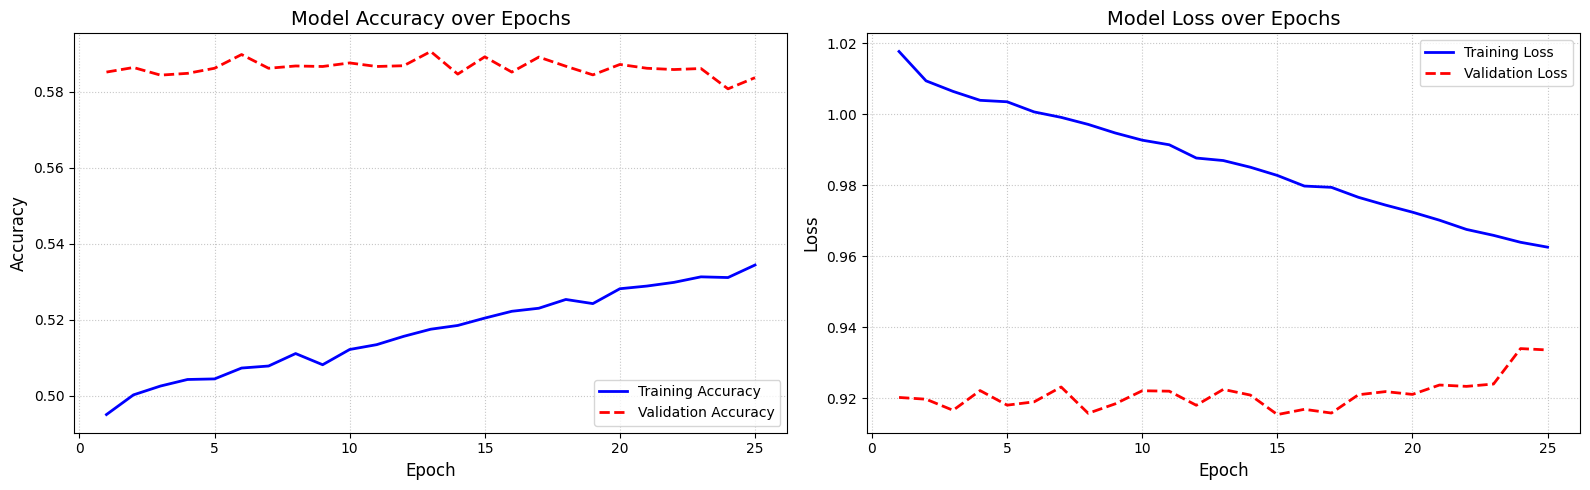

In [ ]:
import matplotlib.pyplot as plt

# Extract data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_run = range(1, len(acc) + 1)

# Create a beautifully formatted 1x2 plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Accuracy
ax1.plot(epochs_run, acc, 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs_run, val_acc, 'r--', label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Loss
ax2.plot(epochs_run, loss, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs_run, val_loss, 'r--', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss over Epochs', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [5]:
# Reinforcement Learning framework
!pip install stable-baselines3 shimmy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 19.5 MB/s eta 0:00:00


In [6]:
import glob
import os
import pandas as pd

SAVE_DIR = '/content/drive/MyDrive/Stock_Project_Data/Raw_Stocks'
all_files = glob.glob(os.path.join(SAVE_DIR, "*_10yr.csv"))

# Initialize an empty dictionary
data_dict = {}

print(f"Found {len(all_files)} stock files. Creating multi-stock data dictionary...")

for file in all_files:
    # Read individual CSV
    temp_df = pd.read_csv(file)

    if not temp_df.empty:
        # Extract the unique stock code from the column
        stock_code = str(temp_df['stock_code_id'].iloc[0])

        # Sort by date if necessary to ensure chronological sequence
        if 'date' in temp_df.columns:
            temp_df = temp_df.sort_values('date').reset_index(drop=True)

        # Store in dictionary with the stock code as the key
        data_dict[stock_code] = temp_df

print(f"Data dictionary created! Total unique stocks loaded: {len(data_dict)}")

Found 30 stock files. Creating multi-stock data dictionary...
Data dictionary created! Total unique stocks loaded: 30


In [7]:
import numpy as np

print("Preprocessing raw data to calculate custom CNN features...")

for ticker, df in data_dict.items():
    close_col = 'close'
    vol_col = 'transaction_volume'

    # Calculate Returns
    df['return'] = df[close_col].pct_change()
    df['log_return'] = np.log(df[close_col] / df[close_col].shift(1))

    # Calculate specific features
    df['z_score_return'] = (df['return'] - df['return'].rolling(window=10).mean()) / (df['return'].rolling(window=10).std() + 1e-8)
    df['ma_5_ratio'] = df[close_col] / df[close_col].rolling(window=5).mean()
    df['ma_10_ratio'] = df[close_col] / df[close_col].rolling(window=10).mean()
    df['volatility'] = df['log_return'].rolling(window=10).std()
    df['vol_ma_10_ratio'] = df[vol_col] / (df[vol_col].rolling(window=10).mean() + 1e-8)

    # 3. Drop the NaN rows generated by the 10-day rolling windows
    df.dropna(subset=['z_score_return', 'ma_5_ratio', 'ma_10_ratio', 'volatility', 'vol_ma_10_ratio'], inplace=True)

    # 4. Reset the index so the RL environment can step through cleanly
    df.reset_index(drop=True, inplace=True)

    # Update the dictionary
    data_dict[ticker] = df

print("✅ Preprocessing complete! Custom features have been appended to all 30 DataFrames.")

Preprocessing raw data to calculate custom CNN features...
✅ Preprocessing complete! Custom features have been appended to all 30 DataFrames.


/tmp/ipykernel_11931/910486462.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return'] = df[close_col].pct_change()
/tmp/ipykernel_11931/910486462.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return'] = df[close_col].pct_change()
/tmp/ipykernel_11931/910486462.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return'] = df[close_col].pct_change()
/tmp/ipykernel_11931/9104

In [8]:
# Grab a sample stock from your new dictionary
sample_ticker = list(data_dict.keys())[0]
sample_df = data_dict[sample_ticker]

# Print the columns and their exact index positions
for i, col in enumerate(sample_df.columns):
    print(f"Index {i}: {col}")

Index 0: date
Index 1: capacity
Index 2: turnover
Index 3: high
Index 4: low
Index 5: close
Index 6: change
Index 7: transaction_volume
Index 8: stock_code_id
Index 9: open
Index 10: stock_code
Index 11: return
Index 12: log_return
Index 13: z_score_return
Index 14: ma_5_ratio
Index 15: ma_10_ratio
Index 16: volatility
Index 17: vol_ma_10_ratio


In [9]:
import gymnasium as gym
from gymnasium import spaces
from tensorflow.keras import Model
from tensorflow.keras.models import load_model
import numpy as np
import joblib

MODEL_PATH = '/content/drive/MyDrive/RL_Stock_Project_Data/trading_model.keras'
SCALER_PATH = '/content/drive/MyDrive/RL_Stock_Project_Data/scaler.pkl'

class TaiwanStockEnv(gym.Env):
    def __init__(self, data_dict, features, episode_length = 150):
        super(TaiwanStockEnv, self).__init__()
        # self.df = df.values
        self.data_dict = data_dict
        self.tickers = list(data_dict.keys())
        self.features = features
        self.episode_length = episode_length
        self.SEQUENCE_LENGTH = 10
        self.NUM_FEATURES = 5

        # Grab a sample dataframe to find where the columns actually live
        sample_df = self.data_dict[self.tickers[0]]
        self.price_idx = sample_df.columns.get_loc('close')

        self.feature_indices = [sample_df.columns.get_loc(f) for f in self.features]
        self.numpy_dict = {ticker: df.values for ticker, df in self.data_dict.items()}

        # ACTION SPACE: 0 = Sell All, 1 = Hold, 2 = Buy (1M NTD)
        self.action_space = spaces.Discrete(3)

        # OBSERVATION SPACE: 64-d CNN features + 2 context vars (Position Lots, Cash Ratio) = 66
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(66,), dtype=np.float32)

        print("Loading model and scaling parameters...")
        model_cnn = load_model(MODEL_PATH)
        self.scaler = joblib.load(SCALER_PATH)

        # CNN feature extractor (assumes layer -2 is the flattened embedding)
        from tensorflow.keras import Sequential
        self.feature_extractor = Sequential(model_cnn.layers[:-2])
        # self.feature_extractor = Model(inputs=model_cnn.input, outputs=model_cnn.layers[-2].output)
        self.reset()

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.current_step = 0

        # Randomly select a stock for this episode
        self.active_ticker = np.random.choice(self.tickers)
        self.active_df = self.numpy_dict[self.active_ticker]

        # Pick a random starting point in the dataframe
        # Ensure we have enough room to go back 10 days (sequence) and forward for the episode
        max_start_idx = len(self.active_df) - self.episode_length - self.SEQUENCE_LENGTH

        if max_start_idx <= 0:
             # Fallback if the dataframe is unusually short
            self.current_step = self.SEQUENCE_LENGTH
        else:
            self.current_step = np.random.randint(self.SEQUENCE_LENGTH, max_start_idx)

        self.end_step = self.current_step + self.episode_length

        # Core financial tracking
        self.initial_capital = 100_000_000 # 100M NTD
        self.cash = self.initial_capital
        self.position_lots = 0
        self.portfolio_value = self.initial_capital
        self.trades_made = 0

        return self._get_observation(), {}

    def _get_observation(self):
        # 1. Grab the 10-day window (2D array)
        data_window = self.active_df[self.current_step : self.current_step + self.SEQUENCE_LENGTH, self.feature_indices]

        # 2. Scale it properly as a 2D array BEFORE reshaping
        scaled_window = self.scaler.transform(data_window)
        X_pred = scaled_window.reshape(1, self.SEQUENCE_LENGTH, self.NUM_FEATURES)

        # 3. Extract the 64-dimensional feature vector
        cnn_features = self.feature_extractor.predict(X_pred, verbose=0)[0]

        # 4. Calculate Context Variables
        cash_ratio = self.cash / self.portfolio_value

        # 5. Append context to CNN features to create a 66-dimensional state
        state = np.concatenate([cnn_features, [self.position_lots, cash_ratio]])

        return state.astype(np.float32)

    def step(self, action):
        # The current day is the end of the 10-day sequence
        current_day_idx = self.current_step + (self.SEQUENCE_LENGTH - 1)
        curr_price = float(self.active_df[current_day_idx, self.price_idx])

        # Record NAV before the action takes effect
        nav_before = self.cash + (self.position_lots * 1000 * curr_price)
        trade_penalty = 0

        # ==========================================
        # EXECUTE ACTION
        # ==========================================
        if action == 2:  # BUY 1M NTD
            FIXED_INVESTMENT = 1000000
            lots_to_buy = int(FIXED_INVESTMENT // (curr_price * 1000))
            cost = lots_to_buy * 1000 * curr_price

            if lots_to_buy > 0 and self.cash >= cost:
                self.cash -= cost
                self.position_lots += lots_to_buy
                self.trades_made += 1
                trade_penalty = cost * 0.001425 # Standard Taiwan Buy Fee
            else:
                trade_penalty = 500 # Minor penalty for attempting an illegal buy without cash

        elif action == 0:  # SELL ALL
            if self.position_lots > 0:
                revenue = self.position_lots * 1000 * curr_price
                self.cash += revenue
                self.position_lots = 0
                self.trades_made += 1
                trade_penalty = revenue * 0.004425 # Standard Taiwan Sell Fee + Tax

        # ==========================================
        # ADVANCE TIME & CALCULATE REWARD
        # ==========================================
        self.current_step += 1
        next_day_idx = self.current_step + (self.SEQUENCE_LENGTH - 1)

        # Check if we hit the end of the dataframe
        terminated = self.current_step >= self.end_step or self.current_step >= len(self.active_df) - 1

        # Get the new price to calculate how much our assets grew/shrank
        next_price = float(self.active_df[next_day_idx, self.price_idx]) if not terminated else curr_price

        # Calculate new NAV
        nav_after = self.cash + (self.position_lots * 1000 * next_price)
        self.portfolio_value = nav_after

        # 1. Step-wise PnL (Includes fees)
        step_pnl = nav_after - nav_before - trade_penalty

        # 2. Downside Volatility Risk Penalty
        reward = step_pnl
        if step_pnl < 0:
            reward -= abs(step_pnl) * 0.15 # Penalize drawdowns an extra 15% to teach risk aversion

        # 3. Neural Network Stability Scaling (Keep rewards roughly between -1 and 1)
        reward = reward / 10000.0

        info = {
            'ticker': self.active_ticker,
            'current_cash': float(self.cash),
            'position_lots': int(self.position_lots),
            'portfolio_value': float(self.portfolio_value),
            'trades_executed': int(self.trades_made)
        }

        return self._get_observation(), float(reward), terminated, False, info

In [18]:
from stable_baselines3.common.callbacks import BaseCallback

class TradingLogCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(TradingLogCallback, self).__init__(verbose)
        self.portfolio_history = []
        self.trades_history = []

    def _on_step(self) -> bool:
        # Access the info dict from the environment
        info = self.locals['infos'][0]

        # Save metrics every single step to plot later
        self.portfolio_history.append(info['portfolio_value'])
        self.trades_history.append(info['trades_executed'])

        # Optional: Print progress every 500 steps so you know it hasn't crashed
        if self.num_timesteps % 500 == 0:
            print(f"Step: {self.num_timesteps} | Ticker: {info['ticker']} | NAV: ${info['portfolio_value']:.2f} | Trades: {info['trades_executed']}")

        return True

In [11]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [12]:
from stable_baselines3 import DQN

features = ['z_score_return', 'ma_5_ratio', 'ma_10_ratio', 'volatility', 'vol_ma_10_ratio']
env = TaiwanStockEnv(data_dict=data_dict, features=features, episode_length=150)

# 1. Instantiate callback just for the 15k run
metrics_callback_15k = TradingLogCallback()

# 2. Instantiate the 15k model
model_15k = DQN("MlpPolicy",
            env,
            learning_rate = 5e-4,
            buffer_size=50_000,
            learning_starts=1_500,
            batch_size=64,
            target_update_interval=1_000,
            policy_kwargs=dict(net_arch=[128, 128]),
            verbose=1)

print("Starting 15k preliminary training...")
model_15k.learn(total_timesteps=15_000, callback=metrics_callback_15k)

# 3. Save the final model directly to your Drive
MODEL_15K_PATH = '/content/drive/MyDrive/Stock_Project_Data/dqn_model_15k'
model_15k.save(MODEL_15K_PATH)

print(f"15k steps training complete - Model saved to: {MODEL_15K_PATH}")
print("Can plot this run using 'metrics_callback_15k.portfolio_history'")

Loading model and scaling parameters...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting 15k preliminary training...
Step: 500 | Ticker: 2882 | NAV: $100062950.00 | Trades: 12
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 150      |
|    ep_rew_mean      | 5.7      |
|    exploration_rate | 0.62     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 12       |
|    time_elapsed     | 46       |
|    total_timesteps  | 600      |
----------------------------------
Step: 1000 | Ticker: 2880 | NAV: $100140000.00 | Trades: 49
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 150      |
|    ep_rew_mean      | -17.6    |
|    exploration_rate | 0.24     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 12       |
|    time_elapsed     | 93       |
|    tota

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_portfolio_history(portfolio_history, title="DQN Agent Training History"):
    """
    Generates a standardized plot for portfolio NAV over training steps.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(portfolio_history, color='#2ca02c', alpha=0.8, linewidth=1.5, label="Portfolio NAV")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Portfolio NAV (NTD)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add a trendline if there is enough data
    if len(portfolio_history) > 1:
        z = np.polyfit(range(len(portfolio_history)), portfolio_history, 1)
        p = np.poly1d(z)
        plt.plot(range(len(portfolio_history)), p(range(len(portfolio_history))), "r--", alpha=0.8, label="Trendline")

    plt.legend()
    plt.tight_layout()
    plt.show()

Displaying 15k Step Model History...


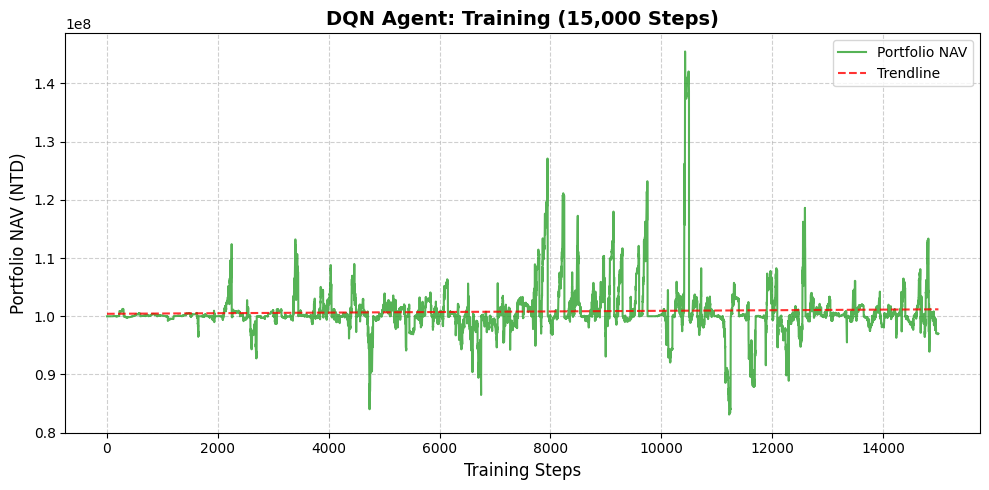

In [14]:
# Plot the 15,000 step run
print("Displaying 15k Step Model History...")
plot_portfolio_history(
    portfolio_history=metrics_callback_15k.portfolio_history,
    title='DQN Agent: Training (15,000 Steps)'
)

In [22]:
import os
import glob
import re
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback, CallbackList

# Setup Checkpoints
CHECKPOINT_DIR = '/content/drive/MyDrive/Stock_Project_Data/RL_Checkpoints/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

TOTAL_STEPS = 150_000

# check for existing checkpoints
checkpoint_files = glob.glob(os.path.join(CHECKPOINT_DIR, "dqn_150k_agent_*_steps.zip"))

latest_checkpoint = None
completed_steps = 0

if checkpoint_files:
    # Find the checkpoint with the highest step count in the filename
    for f in checkpoint_files:
        match = re.search(r'_(\d+)_steps\.zip', f)
        if match:
            step = int(match.group(1))
            if step > completed_steps:
                completed_steps = step
                latest_checkpoint = f

metrics_callback_150k = TradingLogCallback()
checkpoint_callback = CheckpointCallback(
    save_freq=5000,
    save_path=CHECKPOINT_DIR,
    name_prefix='dqn_150k_agent'
)
# Group the callbacks together
combined_callbacks = CallbackList([metrics_callback_150k, checkpoint_callback])

# load existing model or instantiate a model
if latest_checkpoint and completed_steps < TOTAL_STEPS:
    print(f"Resuming from checkpoint: {latest_checkpoint}")
    print(f"Skipping the first {completed_steps} steps.")

    # Load the weights from the saved zip file
    model_150k = DQN.load(latest_checkpoint, env=env)
    model_150k.verbose = 0 # Keep the console clean

    remaining_steps = TOTAL_STEPS - completed_steps
else:
   print("🚀 No checkpoints found. Starting fresh from Step 0...")
   model_150k = DQN("MlpPolicy",
                env,
                learning_rate = 1e-4,
                buffer_size=50_000,
                learning_starts=1_500,
                batch_size=64,
                target_update_interval=1_000,
                policy_kwargs=dict(net_arch=[128, 128]),
                verbose=0) # rely on the custom callback for logging
   remaining_steps = TOTAL_STEPS

# train for whatever time is left
if remaining_steps > 0:
    print(f"Training for the remaining {remaining_steps} steps...")

    # reset_num_timesteps stops SB3 from resetting the internal clock
    # so next checkpoint is named 50,000 instead of reverting to 5,000
    model_150k.learn(
        total_timesteps=remaining_steps,
        callback=combined_callbacks,
        reset_num_timesteps=False
    )

# Save the absolute final model when everything is done
    MODEL_150K_PATH = '/content/drive/MyDrive/Stock_Project_Data/dqn_model_150k_final'
    model_150k.save(MODEL_150K_PATH)
    print(f"150k steps training complete - Final model saved to: {MODEL_150K_PATH}")
else:
    print("Training goal of 150,000 steps already reached.")

print("Can plot this run using 'metrics_callback_150k.portfolio_history'")

🚀 No checkpoints found. Starting fresh from Step 0...
Training for the remaining 150000 steps...
Step: 500 | Ticker: 2603 | NAV: $99609000.00 | Trades: 18
Step: 1000 | Ticker: 2609 | NAV: $100605050.00 | Trades: 58
Step: 1500 | Ticker: 2609 | NAV: $100097400.00 | Trades: 77
Step: 2000 | Ticker: 2303 | NAV: $99838850.00 | Trades: 24
Step: 2500 | Ticker: 3034 | NAV: $100728500.00 | Trades: 40
Step: 3000 | Ticker: 3231 | NAV: $99692350.00 | Trades: 58
Step: 3500 | Ticker: 2308 | NAV: $100066500.00 | Trades: 30
Step: 4000 | Ticker: 2884 | NAV: $100371450.00 | Trades: 63
Step: 4500 | Ticker: 2330 | NAV: $100425000.00 | Trades: 99
Step: 5000 | Ticker: 2892 | NAV: $100118600.00 | Trades: 30
Step: 5500 | Ticker: 2356 | NAV: $99820850.00 | Trades: 67
Step: 6000 | Ticker: 2382 | NAV: $100615500.00 | Trades: 80
Step: 6500 | Ticker: 2912 | NAV: $100193500.00 | Trades: 38
Step: 7000 | Ticker: 2912 | NAV: $100378000.00 | Trades: 78
Step: 7500 | Ticker: 2884 | NAV: $99641750.00 | Trades: 113
Step: 80

Displaying 150k Step Production Model History...


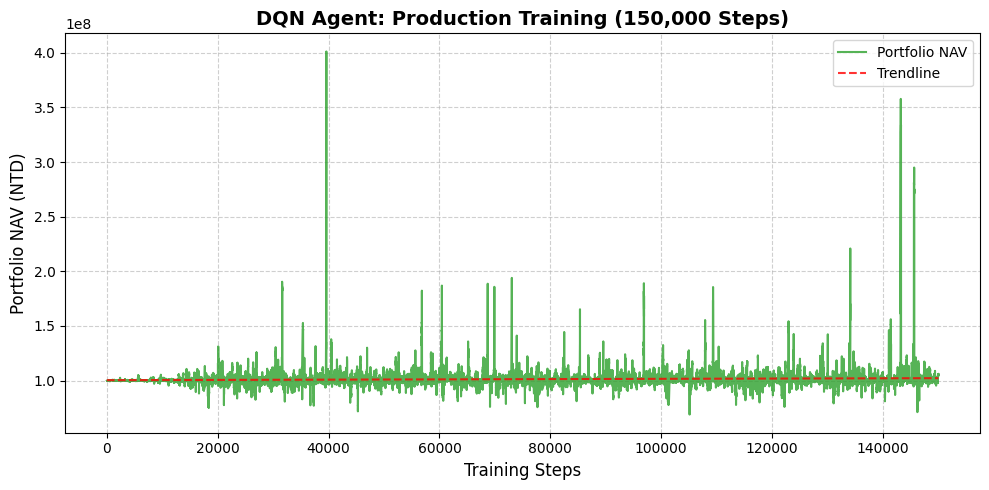

In [23]:
# Plot the 150,000 step production run
print("Displaying 150k Step Production Model History...")
plot_portfolio_history(
    portfolio_history=metrics_callback_150k.portfolio_history,
    title='DQN Agent: Production Training (150,000 Steps)'
)

In [ ]:
target_tickers = [
    '1101', '1102', '1216', '1301', '1303', '1326', '1402', '2002', '2105', '2207',
    '2301', '2303', '2308', '2317', '2324', '2330', '2345', '2353', '2356', '2357',
    '2379', '2382', '2395', '2408', '2409', '2412', '2454', '2603', '2609', '2615',
    '2801', '2880', '2881', '2882', '2883', '2884', '2885', '2886', '2887', '2890',
    '2891', '2892', '2912', '3008', '3034', '3045', '3231', '3481', '3711', '4904',
    '4938', '5871', '5880', '6505', '9904', '1504', '1590', '1605', '1717', '1722',
    '1802', '1907', '2014', '2027', '2101', '2201', '2204', '2304', '2313', '2323',
    '2337', '2344', '2347', '2352', '2362', '2371', '2377', '2383', '2385', '2448',
    '2449', '2451', '2501', '2504', '2542', '2606', '2610', '2618', '2707', '2809',
    '2812', '2834', '2845', '2855', '2903', '2915', '3019', '3037', '3044', '3380'
]

In [ ]:
!pip install yfinance -q

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib

# Load trained model and scaler
MODEL_PATH = '/content/drive/MyDrive/Stock_Project_Data/trading_model.keras'
SCALER_PATH = '/content/drive/MyDrive/Stock_Project_Data/scaler.pkl'

print("Loading model and scaling parameters...")
model = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

features = ['z_score_return', 'ma_5_ratio', 'ma_10_ratio', 'volatility', 'vol_ma_10_ratio']
SEQUENCE_LENGTH = 10
FIXED_CAPITAL_PER_TRADE = 1_000_000 # 1 Million NTD per stock

buy_orders = []

print(f"\Starting Yahoo Finance scan for {len(target_tickers)} tickers...")
print(f"{'Ticker':<8} | {'Status':<12} | {'Rows':<6} | {'Price':<8} | {'Buy Prob':<10} | {'Lots'}")
print("-" * 65)

for index, ticker in enumerate(target_tickers):
    try:

        # Format for Taiwan market in Yahoo Finance (e.g., '2330.TW')
        yf_ticker = f"{ticker}.TW"

        # Pull 1 month of live data directly
        raw_df = yf.download(yf_ticker, period="1mo", progress=False)

        if raw_df.empty or len(raw_df) < 15:
            print(f"{index + 1}. {ticker:<8} | ! - No YF Data  | {'0':<6} | {'-':<8} | {'-':<10} | -")
            print("-" * 75)
            continue

        # Standardize the dataframe to match existing logic
        raw_df = raw_df.reset_index()
        # Ensure column names are lowercase
        raw_df.rename(columns={'Date': 'date', 'Close': 'close', 'Volume': 'volume'}, inplace=True)
        # Handle Pandas multi-index columns from newer yfinance versions if they exist
        if isinstance(raw_df.columns, pd.MultiIndex):
            raw_df.columns = raw_df.columns.get_level_values(0).str.lower()
        else:
            raw_df.columns = raw_df.columns.str.lower()

        row_count = len(raw_df)

        # Calculate the live indicators
        raw_df['log_return'] = np.log(raw_df['close'] / raw_df['close'].shift(1))
        raw_df['ma_5_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=5).mean()
        raw_df['ma_10_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=10).mean()
        raw_df['volatility'] = raw_df['log_return'].rolling(window=10).std()

        # YF Volume can sometimes be 0, adding 1e-8 prevents division by zero
        raw_df['vol_ma_10_ratio'] = raw_df['volume'] / (raw_df['volume'].rolling(window=10).mean() + 1e-8)

        window = 10
        rolling_mean = raw_df['log_return'].rolling(window=window).mean()
        rolling_std = raw_df['volatility']

        raw_df['z_score_return'] = (raw_df['log_return'] - rolling_mean) / (rolling_std + 1e-8)

        feature_df = raw_df.dropna(subset=features)

        if len(feature_df) < SEQUENCE_LENGTH:
            continue

        # Extract sequence, scale, and predict
        latest_sequence = feature_df[features].values[-SEQUENCE_LENGTH:]
        latest_scaled = scaler.transform(latest_sequence)
        X_pred = latest_scaled.reshape(1, SEQUENCE_LENGTH, len(features))

        probs = model.predict(X_pred, verbose=0)[0]
        buy_confidence = probs[0]

        # Ensure price is a clean float
        current_price = float(raw_df['close'].iloc[-1])

        # Position sizing calculation
        shares_to_buy = FIXED_CAPITAL_PER_TRADE / current_price
        lots_to_buy = int(shares_to_buy // 1000)

        # Log the metrics
        print(f"{index + 1}. {ticker:<8} | Success      | {str(row_count):<6} | {current_price:<8.1f} | {buy_confidence*100:<9.1f}% | {lots_to_buy}")

        if lots_to_buy > 0:
            buy_orders.append({
                'Ticker': ticker,
                'Lots': lots_to_buy,
                'Price': current_price,
                'Confidence': buy_confidence * 100
            })

    except Exception as e:
        print(f"{index + 1}. {ticker:<8} | X - Error       | {'-':<6} | {'-':<8} | {'-':<10} | Exception: {str(e)[:20]}")
        continue

# Sort and Output final targets
buy_orders.sort(key=lambda x: x['Confidence'], reverse=True)

print("\n" + "="*60)
print("FINAL EXECUTION TARGETS (TOP 50)")
print("="*60)

trades_to_execute = 50
if buy_orders:
    for idx, order in enumerate(buy_orders[:trades_to_execute]):
        print(f"{idx+1}) BUY {order['Lots']:>3} Lots of {order['Ticker']} at ~{order['Price']:>6.1f} TWD | Buy Prob: {order['Confidence']:.1f}%")
else:
    print("! - The execution list is empty. Market might be returning flat data.")

<>:21: SyntaxWarning: invalid escape sequence '\S'
<>:21: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_2841/3646373785.py:21: SyntaxWarning: invalid escape sequence '\S'
  print(f"\Starting Yahoo Finance scan for {len(target_tickers)} tickers...")
/tmp/ipykernel_2841/3646373785.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


Loading model and scaling parameters...
\Starting Yahoo Finance scan for 100 tickers...
Ticker   | Status       | Rows   | Price    | Buy Prob   | Lots
-----------------------------------------------------------------
1. 1101     | Success      | 23     | 25.0     | 25.8     % | 40


/tmp/ipykernel_2841/3646373785.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


2. 1102     | Success      | 23     | 36.1     | 27.6     % | 27


/tmp/ipykernel_2841/3646373785.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


...

98. 3037     | Success      | 23     | 1015.0   | 45.6     % | 0


/tmp/ipykernel_2841/3646373785.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


99. 3044     | Success      | 23     | 529.0    | 38.0     % | 1


/tmp/ipykernel_2841/3646373785.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


100. 3380     | Success      | 23     | 33.8     | 49.9     % | 29

FINAL EXECUTION TARGETS (TOP 50)
1) BUY  26 Lots of 2324 at ~  37.2 TWD | Buy Prob: 69.0%
2) BUY   3 Lots of 2317 at ~ 259.5 TWD | Buy Prob: 68.4%
3) BUY   6 Lots of 3231 at ~ 160.0 TWD | Buy Prob: 67.8%
4) BUY  40 Lots of 2501 at ~  24.4 TWD | Buy Prob: 65.7%
5) BUY   9 Lots of 2385 at ~ 107.0 TWD | Buy Prob: 63.1%
6) BUY   4 Lots of 2313 at ~ 234.0 TWD | Buy Prob: 61.2%
7) BUY   9 Lots of 4904 at ~ 109.5 TWD | Buy Prob: 59.5%
8) BUY   1 Lots of 2357 at ~ 746.0 TWD | Buy Prob: 58.3%
9) BUY  14 Lots of 3481 at ~  69.1 TWD | Buy Prob: 53.4%
10) BUY  16 Lots of 1326 at ~  61.4 TWD | Buy Prob: 53.3%
11) BUY  29 Lots of 3380 at ~  33.8 TWD | Buy Prob: 49.9%
12) BUY  16 Lots of 1301 at ~  59.2 TWD | Buy Prob: 49.0%
13) BUY   2 Lots of 2382 at ~ 367.5 TWD | Buy Prob: 48.8%
14) BUY  33 Lots of 2409 at ~  29.9 TWD | Buy Prob: 47.9%
15) BUY  19 Lots of 2855 at ~  50.2 TWD | Buy Prob: 46.4%
16) BUY   2 Lots of 2395 at ~ 473.0 TW

In [ ]:
placed_orders = []

In [ ]:
import time
from stock_api import Buy_Stock, Sell_Stock, Get_User_Stocks


print("\n" + "="*60)
print("Automated order submission")
print("="*60)

successful_submissions = 0

ACCOUNT = "P76147051"
PASSWORD = "7051"

# Check if the list exists and has items
if 'buy_orders' in locals() and len(buy_orders) > 0:

    for order in buy_orders[:trades_to_execute]:
        ticker = int(order['Ticker'])
        lots = int(order['Lots'])

        price = round(order['Price'], 2)

        try:
            # API call
            success = Buy_Stock(ACCOUNT, PASSWORD, ticker, lots, price)

            time.sleep(1)

            print(f"Successfully routed BUY order: {lots:>3} Lots of {ticker} at {price} TWD")
            successful_submissions += 1

            placed_orders.append( (str(ticker), lots, float(price)) )

            # A tiny sleep prevents you from DDoSing the university server
            # and getting rate-limited during submission.

        except Exception as e:
            print(f"Failed to route {ticker}. Error: {str(e)}")

    print("\n" + "="*60)
    print(f"EXECUTION COMPLETE: {successful_submissions} trades sent to the server.")
    print("="*60)

else:
    print("No valid orders found in memory. Run the scanner first.")


Automated order submission
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:  26 Lots of 2324 at 37.2 TWD
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:   3 Lots of 2317 at 259.5 TWD
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:   6 Lots of 3231 at 160.0 TWD
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:  40 Lots of 2501 at 24.4 TWD
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:   9 Lots of 2385 at 107.0 TWD
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:   4 Lots of 2313 at 234.0 TWD
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:   9 Lots of 4904 at 109.5 TWD
Buying stock...
Result: success
Status: buy successfully
Successfully routed BUY order:   1 Lots of 2357 at 746.0 TWD
Buying stock...
Result: succes

In [ ]:
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import numpy as np
from stock_api import Sell_Stock, Get_User_Stocks
from tensorflow.keras.models import load_model
import joblib
import time

ACCOUNT = "P76147051"
PASSWORD = "7051"

TARGET_SELLS = 35
TARGET_BUYS = 25

print("Loading model for portfolio evaluation...")
MODEL_PATH = '/content/drive/MyDrive/Stock_Project_Data/trading_model.keras'
SCALER_PATH = '/content/drive/MyDrive/Stock_Project_Data/scaler.pkl'
model = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
features = ['z_score_return', 'ma_5_ratio', 'ma_10_ratio', 'volatility', 'vol_ma_10_ratio']
SEQUENCE_LENGTH = 10

print("\n" + "="*60)
print("Initiating Portfolio Balancing")
print("="*60)

sold_tickers = set() # To prevent rebuying
successful_sells = 0
successful_buys = 0

# 1. Fetch current portfolio
my_stocks = Get_User_Stocks(ACCOUNT, PASSWORD)
evaluated_holdings = []

if my_stocks and len(my_stocks) > 0:
    print(f"Found {len(my_stocks)} active positions. Evaluating momentum...\n")

    for item in my_stocks:

        ticker = str(item['stock_code_id'])
        shares_to_sell = int(item['shares'])
        current_price = float(item['beginning_price'])

        try:
            # Pull live data for the held stock
            yf_ticker = f"{ticker}.TW"
            raw_df = yf.download(yf_ticker, period="1mo", progress=False)

            if raw_df.empty or len(raw_df) < 15:
                continue

            raw_df = raw_df.reset_index()
            raw_df.rename(columns={'Date': 'date', 'Close': 'close', 'Volume': 'volume'}, inplace=True)
            if isinstance(raw_df.columns, pd.MultiIndex):
                raw_df.columns = raw_df.columns.get_level_values(0).str.lower()
            else:
                raw_df.columns = raw_df.columns.str.lower()

            raw_df['log_return'] = np.log(raw_df['close'] / raw_df['close'].shift(1))
            raw_df['ma_5_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=5).mean()
            raw_df['ma_10_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=10).mean()
            raw_df['volatility'] = raw_df['log_return'].rolling(window=10).std()
            raw_df['vol_ma_10_ratio'] = raw_df['volume'] / (raw_df['volume'].rolling(window=10).mean() + 1e-8)

            window = 10
            rolling_mean = raw_df['log_return'].rolling(window=window).mean()
            rolling_std = raw_df['volatility']

            raw_df['z_score_return'] = (raw_df['log_return'] - rolling_mean) / (rolling_std + 1e-8)

            feature_df = raw_df.dropna(subset=features)

            if len(feature_df) < SEQUENCE_LENGTH:
                continue

            latest_sequence = feature_df[features].values[-SEQUENCE_LENGTH:]
            latest_scaled = scaler.transform(latest_sequence)
            X_pred = latest_scaled.reshape(1, SEQUENCE_LENGTH, len(features))

            # Model Prediction: Grab Class 1 (Sell) Probability
            probs = model.predict(X_pred, verbose=0)[0]
            sell_confidence = probs[1]

            evaluated_holdings.append({
                'Ticker': ticker,
                'Shares': shares_to_sell,
                'Price': current_price,
                'Sell_Prob': sell_confidence
            })

        except Exception as e:
            print(f"Could not evaluate {ticker}: {str(e)[:20]}")

    # Rank holdings from Highest Sell Probability to Lowest
    evaluated_holdings.sort(key=lambda x: x['Sell_Prob'], reverse=True)

    # Liquidate the worst positions
    successful_sells = 0

    print("\n" + "-"*60)
    print(f"Executing Sell Orders for the {TARGET_SELLS} weakest momentum assets...")
    print("-"*60)

    for holding in evaluated_holdings[:TARGET_SELLS]:
        t_int = int(holding['Ticker'])
        try:
            success = Sell_Stock(ACCOUNT, PASSWORD, t_int, holding['Shares'], holding['Price'])
            if success:
                print(f"SOLD: {holding['Shares']:>3} Lots of {t_int} | Model Sell Confidence: {holding['Sell_Prob']:.1f}%")
                successful_sells += 1
                sold_tickers.add(holding['Ticker'])
            time.sleep(0.5)
        except Exception as e:
            print(f"Execute Error on {t_int}: {str(e)}")

    print(f"\nLIQUIDATION COMPLETE: {successful_sells} trades logged.")

else:
    print("No stocks found in portfolio.")

Loading model for portfolio evaluation...

Initiating Portfolio Balancing
Found 50 active positions. Evaluating momentum...



/tmp/ipykernel_9424/1475303555.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)
/tmp/ipykernel_9424/1475303555.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)
/tmp/ipykernel_9424/1475303555.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)
/tmp/ipykernel_9424/1475303555.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)
/tmp/ipykernel_9424/1475303555.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)
/tmp/ipykernel_9424/1475303555.py:48: FutureWarning: YF.download() has changed argument auto_adjust 


------------------------------------------------------------
Executing Sell Orders for the 35 weakest momentum assets...
------------------------------------------------------------
Selling stock...
Result: failed
Status: 交易後端連線失敗
Selling stock...
Result: success
Status: sell successfully
SOLD:   5 Lots of 2303 | Model Sell Confidence: 0.5%
Selling stock...
Result: success
Status: sell successfully
SOLD:  14 Lots of 3481 | Model Sell Confidence: 0.4%
Selling stock...
Result: success
Status: sell successfully
SOLD:   1 Lots of 2379 | Model Sell Confidence: 0.4%
Selling stock...
Result: success
Status: sell successfully
SOLD:   6 Lots of 3019 | Model Sell Confidence: 0.4%
Selling stock...
Result: success
Status: sell successfully
SOLD:   1 Lots of 3044 | Model Sell Confidence: 0.4%
Selling stock...
Result: success
Status: sell successfully
SOLD:   8 Lots of 5871 | Model Sell Confidence: 0.4%
Selling stock...
Result: success
Status: sell successfully
SOLD:  33 Lots of 2409 | Model Sell C

In [ ]:
from stock_api import Buy_Stock, Get_User_Stocks

print("\n" + "="*60)
print("SCANNING & BUYING NEW POSITIONS")
print("="*60)

target_tickers = [
    '1101', '1102', '1216', '1301', '1303', '1326', '1402', '2002', '2105', '2207',
    '2301', '2303', '2308', '2317', '2324', '2330', '2345', '2353', '2356', '2357',
    '2379', '2382', '2395', '2408', '2409', '2412', '2454', '2603', '2609', '2615',
    '2801', '2880', '2881', '2882', '2883', '2884', '2885', '2886', '2887', '2890',
    '2891', '2892', '2912', '3008', '3034', '3045', '3231', '3481', '3711', '4904',
    '4938', '5871', '5880', '6505', '9904', '1504', '1590', '1605', '1717', '1722',
    '1802', '1907', '2014', '2027', '2101', '2201', '2204', '2304', '2313', '2323',
    '2337', '2344', '2347', '2352', '2362', '2371', '2377', '2383', '2385', '2448',
    '2449', '2451', '2501', '2504', '2542', '2606', '2610', '2618', '2707', '2809',
    '2812', '2834', '2845', '2855', '2903', '2915', '3019', '3037', '3044', '3380'
]

buy_candidates = []

FIXED_CAPITAL_PER_TRADE = 1_000_000

for ticker in target_tickers:
    if ticker in sold_tickers:
        continue # Skip anything we just sold

    try:
        yf_ticker = f"{ticker}.TW"
        raw_df = yf.download(yf_ticker, period="1mo", progress=False)

        if raw_df.empty or len(raw_df) < 15: continue

        raw_df = raw_df.reset_index()
        raw_df.rename(columns={'Date': 'date', 'Close': 'close', 'Volume': 'volume'}, inplace=True)
        if isinstance(raw_df.columns, pd.MultiIndex):
            raw_df.columns = raw_df.columns.get_level_values(0).str.lower()
        else:
            raw_df.columns = raw_df.columns.str.lower()

        raw_df['log_return'] = np.log(raw_df['close'] / raw_df['close'].shift(1))
        raw_df['ma_5_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=5).mean()
        raw_df['ma_10_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=10).mean()
        raw_df['volatility'] = raw_df['log_return'].rolling(window=10).std()
        raw_df['vol_ma_10_ratio'] = raw_df['volume'] / (raw_df['volume'].rolling(window=10).mean() + 1e-8)

        window = 10
        rolling_mean = raw_df['log_return'].rolling(window=window).mean()
        rolling_std = raw_df['volatility']

        raw_df['z_score_return'] = (raw_df['log_return'] - rolling_mean) / (rolling_std + 1e-8)

        feature_df = raw_df.dropna(subset=features)
        if len(feature_df) < SEQUENCE_LENGTH:
            continue

        latest_sequence = feature_df[features].values[-SEQUENCE_LENGTH:]
        latest_scaled = scaler.transform(latest_sequence)
        X_pred = latest_scaled.reshape(1, SEQUENCE_LENGTH, len(features))

        # Get Buy Probability
        buy_prob = model.predict(X_pred, verbose=0)[0][0]
        current_price = float(raw_df['close'].iloc[-1])

        print("Prediction finished.")

        lots = int((FIXED_CAPITAL_PER_TRADE / current_price) // 1000)

        if lots > 0:
            buy_candidates.append({'Ticker': ticker, 'Lots': lots, 'Price': current_price, 'Buy_Prob': buy_prob})
        else:
            print("No lots to buy.")

    except Exception as e:
        print(f"Prediction Error {t_int}: {e}")
        continue

# Sort and Execute Buys
buy_candidates.sort(key=lambda x: x['Buy_Prob'], reverse=True)

for candidate in buy_candidates[:TARGET_BUYS]:
    t_int = int(candidate['Ticker'])
    price = round(candidate['Price'], 2)
    try:
        if Buy_Stock(ACCOUNT, PASSWORD, t_int, candidate['Lots'], price):
            print(f"BUY: {candidate['Lots']:>3} Lots of {t_int} at {price} | Buy Prob: {candidate['Buy_Prob']*100:.1f}%")
            successful_buys += 1
        time.sleep(0.5)
    except Exception as e:
        print(f"Buy Error {t_int}: {e}")

print("\n" + "="*60)
print(f"🏁 COMPLETION REPORT: {successful_sells} Sells | {successful_buys} Buys | Total: {successful_sells + successful_buys} Trades")
print("="*60)


SCANNING & BUYING NEW POSITIONS


/tmp/ipykernel_9424/3535388118.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


Prediction finished.


/tmp/ipykernel_9424/3535388118.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


Prediction finished.


...

Prediction finished.


/tmp/ipykernel_9424/3535388118.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


Prediction finished.


/tmp/ipykernel_9424/3535388118.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(yf_ticker, period="1mo", progress=False)


Prediction finished.
Buying stock...
Result: failed
Status: 交易後端連線失敗
Buying stock...
Result: failed
Status: 交易後端連線失敗
Buying stock...
Result: success
Status: buy successfully
BUY:   4 Lots of 2313 at 228.0 | Buy Prob: 59.9%
Buying stock...
Result: success
Status: buy successfully
BUY:   2 Lots of 2382 at 367.0 | Buy Prob: 59.1%
Buying stock...
Result: success
Status: buy successfully
BUY:  14 Lots of 1504 at 68.5 | Buy Prob: 59.1%
Buying stock...
Result: success
Status: buy successfully
BUY:   6 Lots of 3231 at 154.5 | Buy Prob: 58.4%
Buying stock...
Result: success
Status: buy successfully
BUY:   1 Lots of 3037 at 998.0 | Buy Prob: 56.5%
Buying stock...
Result: success
Status: buy successfully
BUY:   9 Lots of 4904 at 107.5 | Buy Prob: 48.8%
Buying stock...
Result: success
Status: buy successfully
BUY:   3 Lots of 2451 at 286.0 | Buy Prob: 47.5%
Buying stock...
Result: success
Status: buy successfully
BUY:  25 Lots of 2027 at 39.95 | Buy Prob: 44.9%
Buying stock...
Result: success
Stat

In [ ]:
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import numpy as np
from stock_api import Sell_Stock, Get_User_Stocks
from tensorflow.keras.models import load_model
import joblib
import time

ACCOUNT = "P76147051"
PASSWORD = "7051"

TARGET_SELLS = 1

print("Loading model for portfolio evaluation...")
MODEL_PATH = '/content/drive/MyDrive/Stock_Project_Data/trading_model.keras'
SCALER_PATH = '/content/drive/MyDrive/Stock_Project_Data/scaler.pkl'
model = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
features = ['z_score_return', 'ma_5_ratio', 'ma_10_ratio', 'volatility', 'vol_ma_10_ratio']
SEQUENCE_LENGTH = 10

print("\n" + "="*60)
print("Initiating Portfolio Balancing")
print("="*60)

successful_sells = 0

# 1. Fetch current portfolio
my_stocks = Get_User_Stocks(ACCOUNT, PASSWORD)
evaluated_holdings = []

if my_stocks and len(my_stocks) > 0:
    print(f"Found {len(my_stocks)} active positions. Evaluating momentum...\n")

    for item in my_stocks:

        ticker = str(item['stock_code_id'])
        shares_to_sell = int(item['shares'])
        current_price = float(item['beginning_price'])

        try:
            # Pull live data for the held stock
            yf_ticker = f"{ticker}.TW"
            raw_df = yf.download(yf_ticker, period="1mo", progress=False)

            if raw_df.empty or len(raw_df) < 15:
                continue

            raw_df = raw_df.reset_index()
            raw_df.rename(columns={'Date': 'date', 'Close': 'close', 'Volume': 'volume'}, inplace=True)
            if isinstance(raw_df.columns, pd.MultiIndex):
                raw_df.columns = raw_df.columns.get_level_values(0).str.lower()
            else:
                raw_df.columns = raw_df.columns.str.lower()

            raw_df['log_return'] = np.log(raw_df['close'] / raw_df['close'].shift(1))
            raw_df['ma_5_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=5).mean()
            raw_df['ma_10_ratio'] = raw_df['close'] / raw_df['close'].rolling(window=10).mean()
            raw_df['volatility'] = raw_df['log_return'].rolling(window=10).std()
            raw_df['vol_ma_10_ratio'] = raw_df['volume'] / (raw_df['volume'].rolling(window=10).mean() + 1e-8)

            window = 10
            rolling_mean = raw_df['log_return'].rolling(window=window).mean()
            rolling_std = raw_df['volatility']

            raw_df['z_score_return'] = (raw_df['log_return'] - rolling_mean) / (rolling_std + 1e-8)

            feature_df = raw_df.dropna(subset=features)

            if len(feature_df) < SEQUENCE_LENGTH:
                continue

            latest_sequence = feature_df[features].values[-SEQUENCE_LENGTH:]
            latest_scaled = scaler.transform(latest_sequence)
            X_pred = latest_scaled.reshape(1, SEQUENCE_LENGTH, len(features))

            # Model Prediction: Grab Class 1 (Sell) Probability
            probs = model.predict(X_pred, verbose=0)[0]
            sell_confidence = probs[1]

            evaluated_holdings.append({
                'Ticker': ticker,
                'Shares': shares_to_sell,
                'Price': current_price,
                'Sell_Prob': sell_confidence
            })

        except Exception as e:
            print(f"Could not evaluate {ticker}: {str(e)[:20]}")

    # Rank holdings from Highest Sell Probability to Lowest
    evaluated_holdings.sort(key=lambda x: x['Sell_Prob'], reverse=True)

    # Liquidate the worst positions
    successful_sells = 0

    print("\n" + "-"*60)
    print(f"Executing Sell Orders for the {TARGET_SELLS} weakest momentum assets...")
    print("-"*60)

    for holding in evaluated_holdings[:TARGET_SELLS]:
        t_int = int(holding['Ticker'])
        try:
            success = Sell_Stock(ACCOUNT, PASSWORD, t_int, holding['Shares'], holding['Price'])
            if success:
                print(f"SOLD: {holding['Shares']:>3} Lots of {t_int} | Model Sell Confidence: {holding['Sell_Prob']:.1f}%")
                successful_sells += 1
            time.sleep(0.5)
        except Exception as e:
            print(f"Execute Error on {t_int}: {str(e)}")

    print(f"\nLIQUIDATION COMPLETE: {successful_sells} trades logged.")

else:
    print("No stocks found in portfolio.")

Loading model for portfolio evaluation...

Initiating Portfolio Balancing
No stocks found in portfolio.
